# Kriti Rani
# TASK 2 : Unemployment Analysis with Python
# OASIS INFOBYTE DATA SCIENCE INTERNSHIP

Objective: Unemployment analysis in india during covid-19

This project performs an Exploratory Data Analysis (EDA) on the rate of unemployment in India, specifically evaluating the socio-economic impacts during the COVID-19 pandemic across various regions, months, and areas (Rural vs. Urban).

Goal: Understand fluctuations and spikes in unemployment rates, identify the most impacted regions, and derive trends over time.

Dataset: this dataset Contains 740 non-null observations with key metrics including Estimated Unemployment Rate (%), Estimated Employed, and Estimated Labour Participation Rate (%).

In [1]:
# importing libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
print("importation success! let's start")

importation success! let's start


In [2]:
#Inserting Dataset in Pandas

In [3]:
df = pd.read_csv("Unemployment in India.csv")
df

,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Area
0,Andhra Pradesh,31-05-2019,Monthly,3.65,11999139.0,43.24,Rural
1,Andhra Pradesh,30-06-2019,Monthly,3.05,11755881.0,42.05,Rural
2,Andhra Pradesh,31-07-2019,Monthly,3.75,12086707.0,43.50,Rural
3,Andhra Pradesh,31-08-2019,Monthly,3.32,12285693.0,43.97,Rural
4,Andhra Pradesh,30-09-2019,Monthly,5.17,12256762.0,44.68,Rural
...,...,...,...,...,...,...,...
763,NaN,NaN,NaN,NaN,NaN,NaN,NaN
764,NaN,NaN,NaN,NaN,NaN,NaN,NaN
765,NaN,NaN,NaN,NaN,NaN,NaN,NaN
766,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [4]:
# here, we get to see that the dataset consists of 768 rows and 7 columns

In [5]:
df.describe()

,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%)
count,740.000000,7.400000e+02,740.000000
mean,11.787946,7.204460e+06,42.630122
std,10.721298,8.087988e+06,8.111094
min,0.000000,4.942000e+04,13.330000
25%,4.657500,1.190404e+06,38.062500
50%,8.350000,4.744178e+06,41.160000
75%,15.887500,1.127549e+07,45.505000
max,76.740000,4.577751e+07,72.570000


In [6]:
# using df.describe() we get to see the description of the dataset onto 7 parameters: count, mean, standard deviation, minimum, maximum, 25%, 50%, and 75%.

Cleaning the column names by stripping leading/trailing whitespace:

In [7]:
df.columns = df.columns.str.strip()

In [8]:
#Checking the dataset shape and missing values:

In [9]:
print("Dataset Shape:", df.shape)
print("\nMissing Values:")
print(df.isnull().sum())

Dataset Shape: (768, 7)

Missing Values:
Region                                     28
Date                                       28
Frequency                                  28
Estimated Unemployment Rate (%)            28
Estimated Employed                         28
Estimated Labour Participation Rate (%)    28
Area                                       28
dtype: int64


In [10]:
#upon inspecion, we get to see the shape of the dataset.

In [11]:
# Display data types
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 7 columns):
 #   Column                                   Non-Null Count  Dtype  
---  ------                                   --------------  -----  
 0   Region                                   740 non-null    str    
 1   Date                                     740 non-null    str    
 2   Frequency                                740 non-null    str    
 3   Estimated Unemployment Rate (%)          740 non-null    float64
 4   Estimated Employed                       740 non-null    float64
 5   Estimated Labour Participation Rate (%)  740 non-null    float64
 6   Area                                     740 non-null    str    
dtypes: float64(3), str(4)
memory usage: 66.1 KB


In [12]:
#using the df.info(), we got all the information related to our dataset- be it the elements' dtypes, memory usage or their range of indices, we got all the info.

# Data Cleaning & Date Conversion

In [13]:
# Drop rows with null values if any exist
df = df.dropna()

In [14]:
# Converting 'Date' to datetime format

In [15]:
df['Date'] = pd.to_datetime(df['Date'].str.strip(), format='%d-%m-%Y')

In [16]:
# Extract month and year for aggregated trends
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month_name()

df

,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Area,Year,Month
0,Andhra Pradesh,2019-05-31,Monthly,3.65,11999139.0,43.24,Rural,2019,May
1,Andhra Pradesh,2019-06-30,Monthly,3.05,11755881.0,42.05,Rural,2019,June
2,Andhra Pradesh,2019-07-31,Monthly,3.75,12086707.0,43.50,Rural,2019,July
3,Andhra Pradesh,2019-08-31,Monthly,3.32,12285693.0,43.97,Rural,2019,August
4,Andhra Pradesh,2019-09-30,Monthly,5.17,12256762.0,44.68,Rural,2019,September
...,...,...,...,...,...,...,...,...,...
749,West Bengal,2020-02-29,Monthly,7.55,10871168.0,44.09,Urban,2020,February
750,West Bengal,2020-03-31,Monthly,6.67,10806105.0,43.34,Urban,2020,March
751,West Bengal,2020-04-30,Monthly,15.63,9299466.0,41.20,Urban,2020,April
752,West Bengal,2020-05-31,Monthly,15.22,9240903.0,40.67,Urban,2020,May


In [17]:
#here, we dropped the null valued rows, converted date to datetime format(%d-%m-%Y), and extracted the month and year, using the datetime concepts.

# Region-Wise & Month-Wise EDA
Analyzing average unemployment across regions and overall monthly trends:

In [18]:
# Region-wise average unemployment rate
region_avg = df.groupby('Region')['Estimated Unemployment Rate (%)'].mean().reset_index()
print("Region-Wise Averages:")
print(region_avg.head())

Region-Wise Averages:
           Region  Estimated Unemployment Rate (%)
0  Andhra Pradesh                         7.477143
1           Assam                         6.428077
2           Bihar                        18.918214
3      Chandigarh                        15.991667
4    Chhattisgarh                         9.240357


In [19]:
# using df.groupby(), the grouping of the regionwise est. unemployment rates, by calculating the mean of them is done.

In [20]:
# Month-wise average unemployment rate
month_avg = df.groupby('Month')['Estimated Unemployment Rate (%)'].mean().reset_index()
print("\nMonth-Wise Averages:")
print(month_avg)


Month-Wise Averages:
        Month  Estimated Unemployment Rate (%)
0       April                        23.641569
1      August                         9.637925
2    December                         9.497358
3    February                         9.964717
4     January                         9.950755
5        July                         9.033889
6        June                        10.553462
7       March                        10.700577
8         May                        16.646190
9    November                         9.868364
10    October                         9.900909
11  September                         9.051731


In [21]:
# the same task of grouping the est. unemployment rate, by calculation of their mean is done, but grouped into monthwise manner this time.

# Creation of Top 10 States Bar Chart

In [22]:
# Creating a bar chart displaying the 10 states with the highest average unemployment rate:

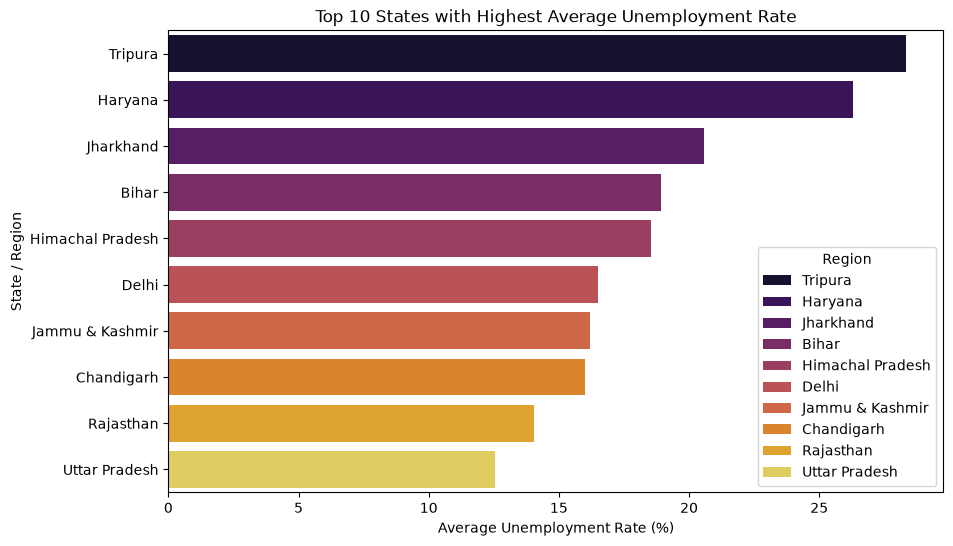

In [23]:
plt.figure(figsize=(10, 6))
top_10 = region_avg.sort_values(by='Estimated Unemployment Rate (%)', ascending=False).head(10)

sns.barplot(x='Estimated Unemployment Rate (%)', y = 'Region', data = top_10, hue = 'Region',legend = True, palette = 'inferno')
plt.title('Top 10 States with Highest Average Unemployment Rate')
plt.xlabel('Average Unemployment Rate (%)')
plt.ylabel('State / Region')
plt.show()

In [24]:
#here, using the concepts of matplotlib,plotting the indices using inferno palatte, we get the data of top 10 states with highest avg unemployment rate plotted. The highest of them being Tripura, followed by Haryana, Jharkhand, and all, the 10th one being UP

# Time-Series Line Chart for Major States

In [25]:
# Plotting unemployment rates over time for 3 major states

In [ ]:
plt.figure(figsize=(10, 6))
states = ['Andhra Pradesh', 'Maharashtra', 'West Bengal']
filtered_df = df[df['Region'].isin(states)]

sns.lineplot(x='Date', y='Estimated Unemployment Rate (%)', hue='Region', data=filtered_df, marker='+')
plt.title('Unemployment Rate Over Time for Selected States')
plt.xlabel('Date')
plt.ylabel('Unemployment Rate (%)')
plt.xticks(rotation=50)
plt.show()

In [ ]:
#here, we plotted time series line chart for 3 major states- Haryana, Bihar, and Uttar Pradesh, to which we observed that the unemployment rates vary majorly: Bihar>Haryana>UP

# Correlation Heatmap

In [ ]:
# Plotting a heatmap showing correlations between unemployment, employment, and labor participation rates:

In [ ]:
plt.figure(figsize=(6, 4))
cols = ['Estimated Unemployment Rate (%)', 'Estimated Employed', 'Estimated Labour Participation Rate (%)']
sns.heatmap(df[cols].corr(), annot=True, cmap='seismic', fmt=".2f")
plt.title('Correlation Heatmap')
plt.show()

In [ ]:
# the correlation heatmap has been plotted

# Pre-COVID vs. Post-COVID Comparison

In [ ]:
# Split data into Pre-COVID (before March 2020) and Post-COVID (March 2020 onwards)
pre_covid = df[df['Date'] < '2020-03-01']
post_covid = df[df['Date'] >= '2020-03-01']

pre_mean = pre_covid['Estimated Unemployment Rate (%)'].mean()
post_mean = post_covid['Estimated Unemployment Rate (%)'].mean()

print(f"Pre-COVID Average Unemployment Rate: {pre_mean:.2f}%")
print(f"Post-COVID Average Unemployment Rate: {post_mean:.2f}%")

# Quick comparison bar plot
plt.figure(figsize=(6, 4))
sns.barplot(x=['Pre-COVID', 'Post-COVID'], y=[pre_mean, post_mean], hue=['Pre-COVID', 'Post-COVID'], palette='Set2', legend=True)
plt.title('Pre-COVID vs Post-COVID Unemployment Rate Comparison')
plt.ylabel('Mean Unemployment Rate (%)')
plt.show()

upon inspecting the plotted pre vs post covid unemployment rate comparison, we see that the pre covid rate was 9.51%, and the post covid rate was 17.77%

# Conclusion

Pandemic Impact Peak: The Average national unemployment spiked sharply in April 2020 (23.64%) and May 2020 (16.65%), directly coinciding with the nationwide COVID-19 lockdown implementation, compared to pre-lockdown levels which hovered around 9–10%.

State Vulnerability: States like Bihar (18.92%) and Chandigarh (15.99%) exhibited significantly higher average unemployment rates compared to lower-rate regions like Assam (6.43%) and Andhra Pradesh (7.48%).

Wide Variance: The dataset reveals extreme volatility during this period, with local unemployment rates ranging from 0.0% up to a maximum peak of 76.74%.